# 01 - Demographics

Who gets rated in NBA 2K26? Before validating the game's Overall rating against real
performance, it's worth understanding the shape of the rated player population itself: age,
position, height/weight/wingspan, nationality/college, and team distribution.

This notebook uses the cleaned NBA 2K26 ratings dataset
(`data/processed/players_2k26_clean.csv`, 377 players). **Important caveat** (see the
project README for the full explanation): this is not the full ~550-player NBA roster - it's
whichever ~377 players had a 2kratings.com page crawled by the Internet Archive's Wayback
Machine during the NBA 2K26 window (Aug 2025 - Feb 2026), since the live 2kratings.com site
has since rolled forward to previewing NBA 2K27. Bench/two-way/mid-season-signee players are
under-represented relative to rotation regulars and stars.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/processed/players_2k26_clean.csv")
print(f"{len(df):,} players, {df.shape[1]} columns")
df.head()

377 players, 66 columns


,slug,name,team,nationality,position,position2,archetype,height_ftin,height_cm,weight_lb,...,speed,speed_with_ball,stamina,standing_dunk,steal,strength,three_point_shot,vertical,name_norm,age_2k
0,aaron-gordon,Aaron Gordon,Denver Nuggets,United States,PF,NaN,2-Way 3-Level Scorer,"6'8""",203.0,235.0,...,71.0,66.0,95.0,85.0,33.0,72.0,88.0,92.0,aaron gordon,30
1,aaron-holiday,Aaron Holiday,Houston Rockets,United States,PG,SG,Sharpshooting Shot Creator,"6'0""",183.0,185.0,...,76.0,76.0,85.0,25.0,43.0,49.0,83.0,56.0,aaron holiday,29
2,aaron-nesmith,Aaron Nesmith,Indiana Pacers,United States,SF,PF,3 & D Wing,"6'5""",196.0,215.0,...,78.0,64.0,87.0,35.0,43.0,52.0,86.0,79.0,aaron nesmith,26
3,ace-bailey,Ace Bailey,Utah Jazz,United States,SF,SG,Blow-By Laymaking Wing,"6'10""",208.0,200.0,...,85.0,NaN,88.0,60.0,NaN,61.0,79.0,79.0,ace bailey,19
4,adama-sanogo,Adama Sanogo,Free Agency,Mali,C,PF,NaN,"6'9""",206.0,245.0,...,70.0,49.0,80.0,70.0,46.0,71.0,69.0,62.0,adama sanogo,23


## Age

The scrape doesn't include a ready-made `age` column, so we compute it from `birthdate`
relative to October 1, 2025 - roughly when NBA 2K26 launched and the 2025-26 NBA season
tipped off, so ages line up with the season we validate against in notebook 02.

In [2]:
REFERENCE_DATE = pd.Timestamp("2025-10-01")

df["birthdate_parsed"] = pd.to_datetime(df["birthdate"], errors="coerce")
df["age"] = ((REFERENCE_DATE - df["birthdate_parsed"]).dt.days / 365.25)
print(f"{df['birthdate_parsed'].isna().sum()} players with unparseable birthdate")
df["age"].describe()

0 players with unparseable birthdate


count    377.000000
mean      27.000525
std        4.364629
min       18.778919
25%       23.813826
50%       26.220397
75%       29.297741
max       40.752909
Name: age, dtype: float64

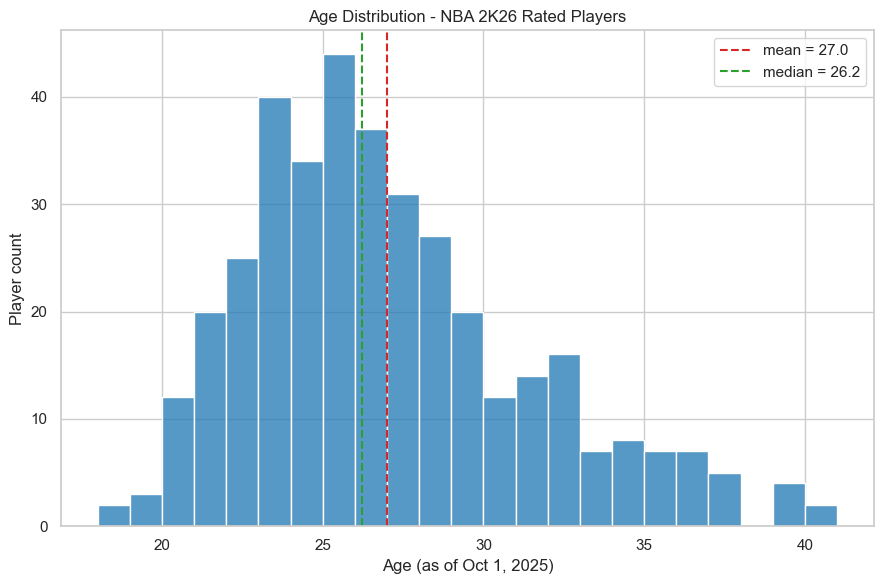

Mean age: 27.00, median: 26.2, std: 4.36
Youngest: 18.8, oldest: 40.8
Under 23: 16.4% of players
Over 32: 14.9% of players


In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(df["age"].dropna(), bins=range(18, 42), color="#1f77b4", ax=ax)
ax.axvline(df["age"].mean(), color="#d62728", ls="--", lw=1.5, label=f"mean = {df['age'].mean():.1f}")
ax.axvline(df["age"].median(), color="#2ca02c", ls="--", lw=1.5, label=f"median = {df['age'].median():.1f}")
ax.set_title("Age Distribution - NBA 2K26 Rated Players")
ax.set_xlabel("Age (as of Oct 1, 2025)")
ax.set_ylabel("Player count")
ax.legend()
plt.tight_layout()
plt.show()

age_summary = df["age"].describe()
pct_u23 = (df["age"] < 23).mean() * 100
pct_over32 = (df["age"] > 32).mean() * 100
print(f"Mean age: {age_summary['mean']:.2f}, median: {age_summary['50%']:.1f}, std: {age_summary['std']:.2f}")
print(f"Youngest: {df['age'].min():.1f}, oldest: {df['age'].max():.1f}")
print(f"Under 23: {pct_u23:.1f}% of players")
print(f"Over 32: {pct_over32:.1f}% of players")

**Takeaway:** the rated pool skews slightly older than a random cross-section of the
league would, centered in the mid-to-late 20s. This is a direct consequence of the sampling
mechanism described above - the Wayback Machine crawl is more likely to have hit established,
searched-for veterans and stars than a rookie or two-way player who just joined a roster, so
the tail of players over 32 is proportionally fatter than it would be if every active NBA
player were included.

## Position distribution

2kratings.com assigns each player a primary position (PG/SG/SF/PF/C); some players also carry
a secondary position.

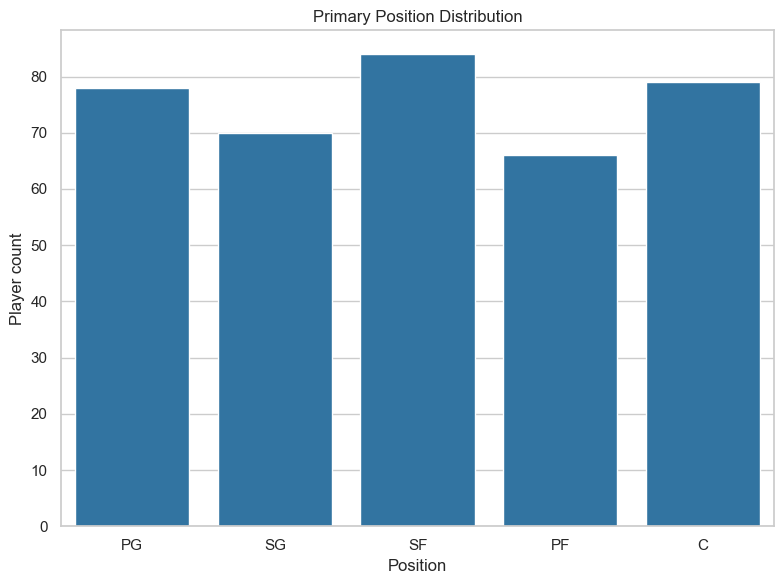

position
PG    78
SG    70
SF    84
PF    66
C     79
Name: count, dtype: int64

In [4]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
pos_counts = df["position"].value_counts().reindex(pos_order)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=pos_counts.index, y=pos_counts.values, order=pos_order, ax=ax, color="#1f77b4")
ax.set_title("Primary Position Distribution")
ax.set_xlabel("Position")
ax.set_ylabel("Player count")
plt.tight_layout()
plt.show()

pos_counts

In [5]:
has_secondary = df["position2"].notna().mean() * 100
print(f"{has_secondary:.1f}% of players have a listed secondary position")
df["position2"].value_counts().head(10)

78.0% of players have a listed secondary position


position2
SG    96
SF    76
PF    69
C     27
PG    26
Name: count, dtype: int64

**Takeaway:** the five traditional positions are close to evenly represented (roughly
67-84 players each), with SF the single largest group and PF the smallest in this sample -
consistent with there being no structural reason a Wayback-crawl-driven sample would skew
toward any one position, unlike age (where career prominence does correlate with position to
some degree, e.g. star wings/bigs get crawled more than end-of-bench guards).

## Height, weight & wingspan

2K's bio panel lists height, weight, and wingspan - the latter is a defense/rim-protection
proxy not captured by height alone (a long wingspan relative to height is a well-known
scouting plus).

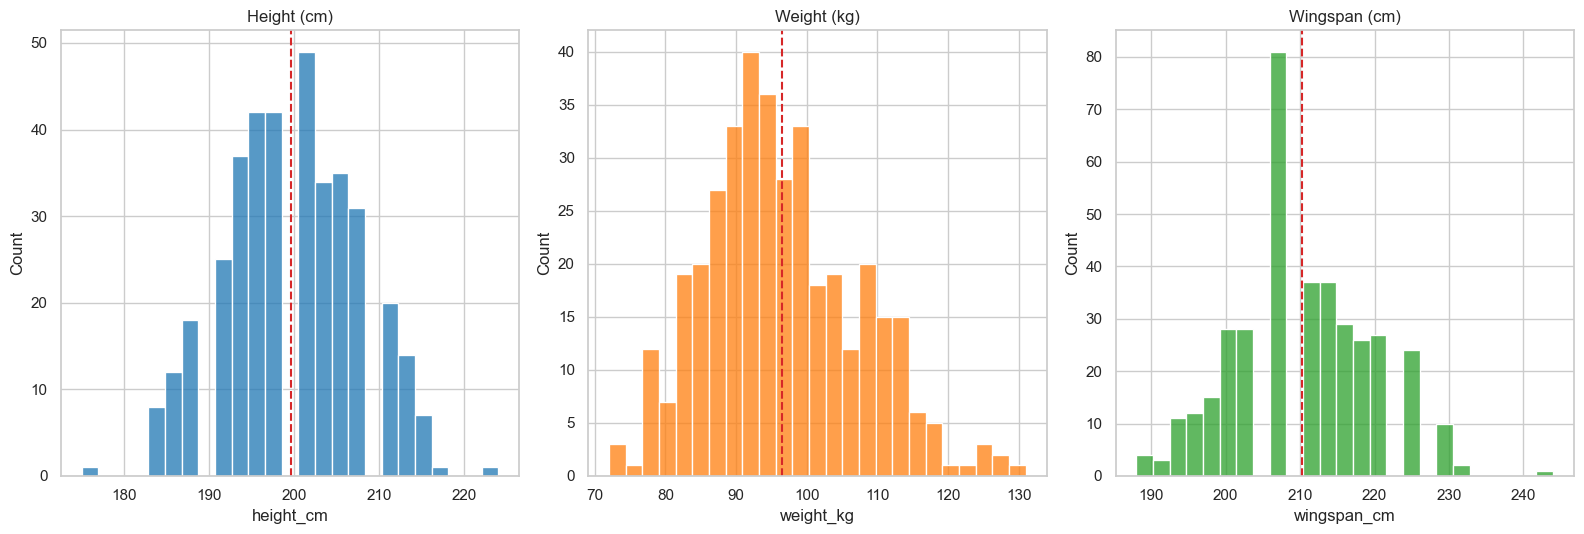

Height: mean 199.7cm, std 8.0, range 175-224
Weight: mean 96.5kg, std 10.6, range 72-131
Wingspan: mean 210.2cm, std 9.3
Wingspan - height: mean 10.6cm (positive = longer arms than height)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
sns.histplot(df["height_cm"], bins=25, color="#1f77b4", ax=axes[0])
axes[0].set_title("Height (cm)")
axes[0].axvline(df["height_cm"].mean(), color="#d62728", ls="--", lw=1.5)

sns.histplot(df["weight_kg"], bins=25, color="#ff7f0e", ax=axes[1])
axes[1].set_title("Weight (kg)")
axes[1].axvline(df["weight_kg"].mean(), color="#d62728", ls="--", lw=1.5)

sns.histplot(df["wingspan_cm"].dropna(), bins=25, color="#2ca02c", ax=axes[2])
axes[2].set_title("Wingspan (cm)")
axes[2].axvline(df["wingspan_cm"].mean(), color="#d62728", ls="--", lw=1.5)

plt.tight_layout()
plt.show()

print(f"Height: mean {df['height_cm'].mean():.1f}cm, std {df['height_cm'].std():.1f}, range {df['height_cm'].min():.0f}-{df['height_cm'].max():.0f}")
print(f"Weight: mean {df['weight_kg'].mean():.1f}kg, std {df['weight_kg'].std():.1f}, range {df['weight_kg'].min():.0f}-{df['weight_kg'].max():.0f}")
print(f"Wingspan: mean {df['wingspan_cm'].mean():.1f}cm, std {df['wingspan_cm'].std():.1f}")
df["wingspan_minus_height"] = df["wingspan_cm"] - df["height_cm"]
print(f"Wingspan - height: mean {df['wingspan_minus_height'].mean():.1f}cm (positive = longer arms than height)")

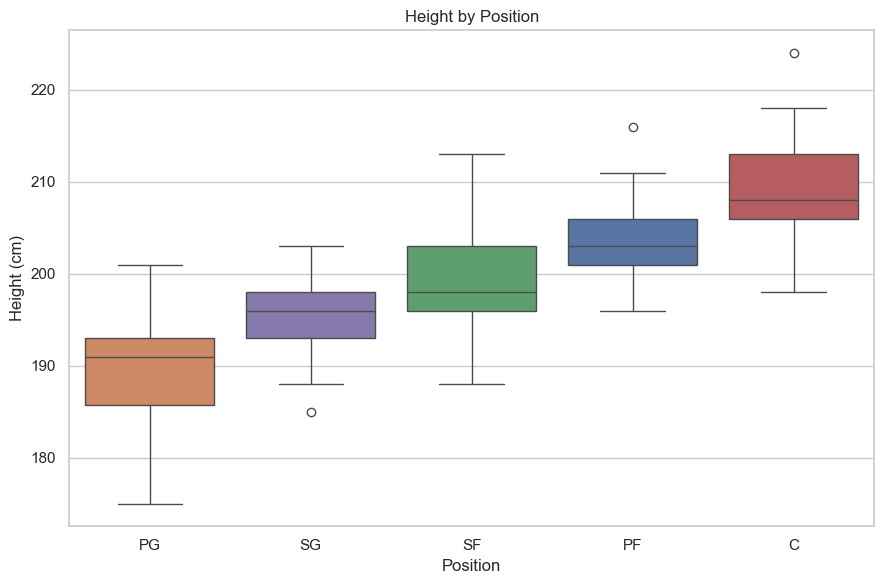

position
PG    190.3
SG    195.3
SF    199.6
PF    203.9
C     209.3
Name: height_cm, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = df.dropna(subset=["position"])
sns.boxplot(data=plot_df, x="position", y="height_cm", order=pos_order, hue="position", legend=False, ax=ax, palette="deep")
ax.set_title("Height by Position")
ax.set_xlabel("Position")
ax.set_ylabel("Height (cm)")
plt.tight_layout()
plt.show()

plot_df.groupby("position")["height_cm"].mean().reindex(pos_order).round(1)

**Takeaway:** height increases monotonically from PG to C as expected (a basic sanity
check that the scraped bio data is coherent), and the average player's wingspan exceeds their
height by several centimeters - a well-documented feature of elite basketball populations
(long arms relative to standing height help with rebounding, shot contests, and passing
lanes), not an artifact of the data.

## Nationality & college

The `nationality` field captures where a player is from. `college` is really a "prior to the
NBA" field: for most American players it's their NCAA program, but for international players
who never played US college ball, 2kratings.com fills it with their pre-NBA pro club/league
instead (e.g. "Perth Wildcats (NBL, Australia)" for Alexandre Sarr, or just their home
country's name for a couple of players who came up through a national federation program
rather than a named club) - so a high "has college" fill rate doesn't mean nearly everyone
played US college basketball.

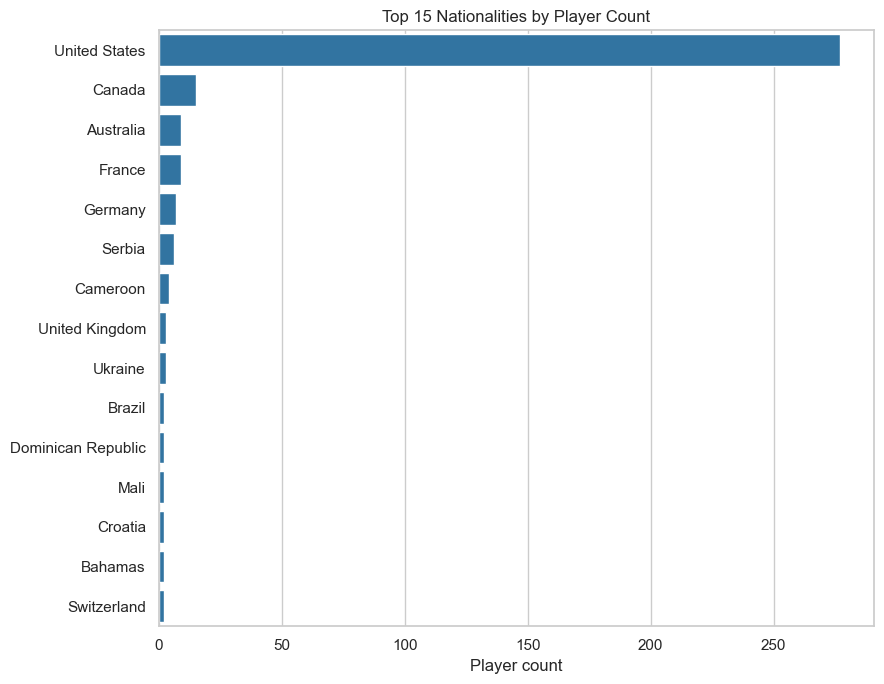

41 distinct nationalities represented
United States: 73.5% of players


nationality
United States         277
Canada                 15
Australia               9
France                  9
Germany                 7
Serbia                  6
Cameroon                4
United Kingdom          3
Ukraine                 3
Brazil                  2
Dominican Republic      2
Mali                    2
Croatia                 2
Bahamas                 2
Switzerland             2
Name: count, dtype: int64

In [8]:
top_nations = df["nationality"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=top_nations.values, y=top_nations.index, ax=ax, color="#1f77b4")
ax.set_title("Top 15 Nationalities by Player Count")
ax.set_xlabel("Player count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

pct_us = (df["nationality"] == "United States").mean() * 100
print(f"{df['nationality'].nunique()} distinct nationalities represented")
print(f"United States: {pct_us:.1f}% of players")
top_nations

In [9]:
has_college = df["college"].notna().mean() * 100
print(f"{has_college:.1f}% of players have a listed college")
top_colleges = df["college"].value_counts().head(15)
top_colleges

99.2% of players have a listed college


college
Duke                   20
Kentucky               17
Michigan               10
UCLA                   10
Arizona                 9
Gonzaga                 8
Memphis                 7
Kansas                  7
NBA G League Ignite     7
Auburn                  7
Virginia                7
Arkansas                7
Villanova               6
Ohio State              6
Alabama                 6
Name: count, dtype: int64

**Takeaway:** the pool is overwhelmingly American, with the international share made up
mostly of Canada, Australia, France, and Germany - reflecting both the NBA's historical
American core and its growing (but still minority) pipeline of international prospects. Among
the majority of players with a listed college, no single program dominates -- big-name
basketball schools appear near the top of the list but each supplies only a handful of the
league's current rated players, since one-and-done departures and international/G-League
routes have fragmented the traditional "blue blood" college pipeline somewhat.

## Team distribution & free agency

Since the ratings are a point-in-time snapshot (mostly the initial Aug 2025 launch rating),
some players in the dataset were free agents or between rosters when their page was archived.

63 players (16.7%) listed as Free Agency


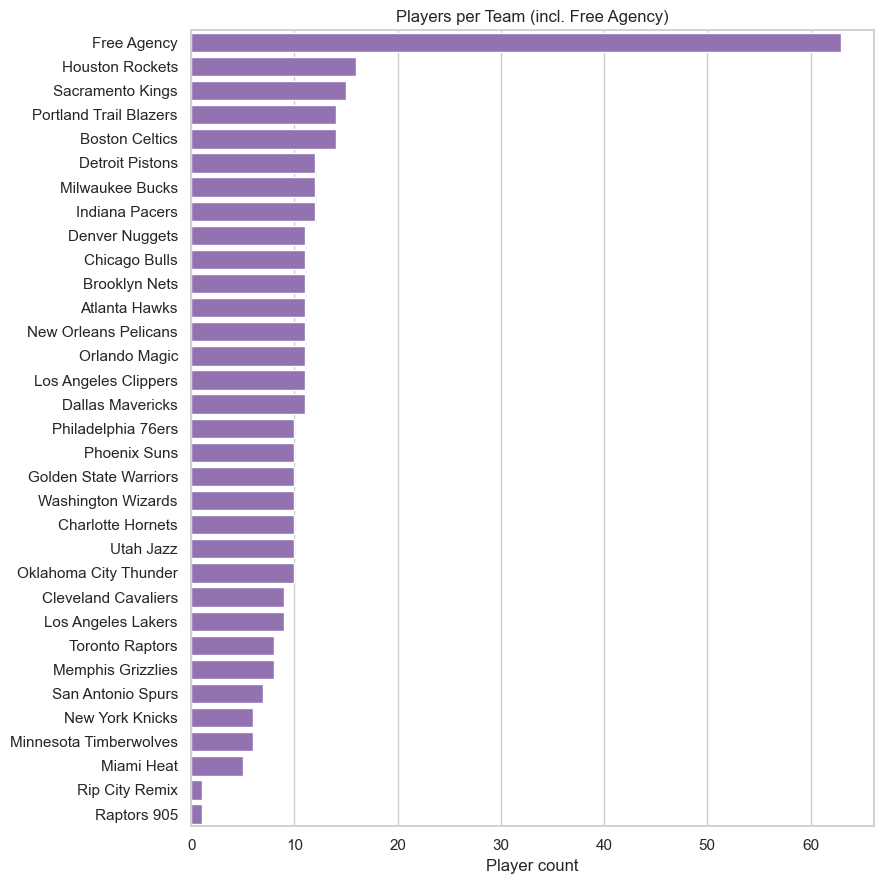

In [10]:
team_counts = df["team"].value_counts()
print(f"{team_counts.get('Free Agency', 0)} players ({team_counts.get('Free Agency', 0)/len(df)*100:.1f}%) listed as Free Agency")

fig, ax = plt.subplots(figsize=(9, 9))
sns.barplot(x=team_counts.values, y=team_counts.index, ax=ax, color="#9467bd")
ax.set_title("Players per Team (incl. Free Agency)")
ax.set_xlabel("Player count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Takeaway:** "Free Agency" is the single largest bucket, but that's a data-snapshot
artifact rather than a real roster imbalance - 2K periodically updates a player's `team` field
as trades/signings happen, and an archived page can catch a player mid-transition (waived,
between two-way deals, etc.). Actual per-team counts among rostered players are otherwise
reasonably even, consistent with a real slice of every team's roster being represented rather
than the sample being concentrated on a handful of teams.

## Overall rating, potential, and archetype

Finally, a look at the ratings themselves: the `overall` distribution, the `archetype` labels
2K assigns to each player's play style, and the `potential_grade` field.

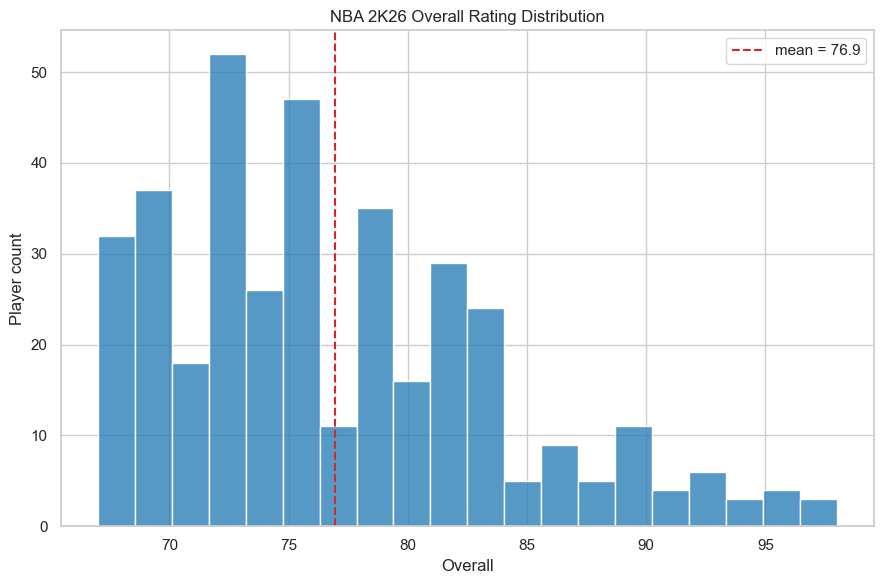

count    377.000000
mean      76.938992
std        6.911214
min       67.000000
25%       72.000000
50%       75.000000
75%       81.000000
max       98.000000
Name: overall, dtype: float64

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(df["overall"], bins=20, color="#1f77b4", ax=ax)
ax.axvline(df["overall"].mean(), color="#d62728", ls="--", lw=1.5, label=f"mean = {df['overall'].mean():.1f}")
ax.set_title("NBA 2K26 Overall Rating Distribution")
ax.set_xlabel("Overall")
ax.set_ylabel("Player count")
ax.legend()
plt.tight_layout()
plt.show()

df["overall"].describe()

In [12]:
top_archetypes = df["archetype"].value_counts().head(15)
print(f"{df['archetype'].notna().mean()*100:.1f}% of players have a listed archetype ({df['archetype'].nunique()} distinct archetypes)")
top_archetypes

80.6% of players have a listed archetype (172 distinct archetypes)


archetype
Shot-Creating 3-Level Threat    10
2-Way 3-Level Shot Creator       8
Crafty Sharpshooter              7
Inside-Out Scoring Threat        7
Iso Sniper                       7
Rim Attacker                     7
Stretch Four                     7
Perimeter Shot Creator           6
Offensive Architect              5
Interior Threat                  5
Catch & Shoot Threat             4
2-Way 3-Level Scoring Threat     4
Defensive Menace                 4
3-Level Scoring Threat           4
Mid-Range Scoring Threat         4
Name: count, dtype: int64

**Takeaway:** the Overall distribution is centered in the mid-to-high 70s with a long right
tail toward the rare 90+ superstar ratings, the expected shape for a rating system designed so
only a handful of players sit at the very top. Archetype labels are highly fragmented - the
most common single archetype covers only a handful of players out of dozens of distinct
labels - reflecting 2K's design goal of giving most rated players a fairly bespoke play-style
descriptor rather than bucketing everyone into a few generic templates.

## Summary

- The rated pool skews toward established veterans/stars rather than a uniform sample of the
  league, a direct consequence of relying on Wayback Machine crawl coverage rather than a
  full-roster source.
- The five traditional positions (PG/SG/SF/PF/C) are fairly evenly represented; height
  increases monotonically from guards to centers, a basic sanity check on the scraped bio
  data, and average wingspan exceeds average height by several centimeters as expected for an
  elite basketball population.
- The pool is heavily (but not exclusively) American, with a modest international
  contingent led by Canada, Australia, France, and Germany; the college pipeline is
  fragmented across many programs rather than dominated by a few blue-bloods.
- "Free Agency" is the largest single `team` bucket, a data-snapshot artifact of the
  point-in-time archive crawl rather than a real roster concentration.
- Overall ratings are right-skewed around the mid-to-high 70s, and archetype labels are
  highly fragmented across dozens of distinct play-style descriptors - both consistent with a
  rating system designed to differentiate players individually rather than bucket them
  coarsely. These demographic patterns set up notebook 02's validation of `overall` (and the
  attribute categories) against real 2025-26 stats and salary.